In [1]:
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('tensorflow-addons is optional for this project.')

2026-05-15 21:38:16.791220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778881097.012078      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778881097.075389      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778881097.582183      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778881097.582229      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778881097.582232      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
tensorflow-addons is optional for this project.


In [ ]:
# Clone this branch from GitHub: Forensicore
!rm -rf /kaggle/working/swin-model
!git clone -b Forensicore https://github.com/RafiaMushtaq04/swin-model.git /kaggle/working/swin-model


Cloning into '/kaggle/working/swin-model'...
remote: Enumerating objects: 429, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 429 (delta 36), reused 37 (delta 23), pack-reused 374 (from 1)
Receiving objects: 100% (429/429), 509.50 KiB | 22.15 MiB/s, done.
Resolving deltas: 100% (249/249), done.



Dataset Image Size Scan
Top image sizes (height, width) from sampled files:
- (256, 256) -> 2335 samples
- (224, 224) -> 624 samples
- (600, 600) -> 41 samples
Fixed mode: forcing resize to (224, 224)
Note: most common dataset size is (256, 256), but fixed size is (224, 224)

Run Configuration
MODEL_NAME: ForensiCore-Video
input_shape: (224, 224, 3)
NUM_CLASSES: 2
PATCH_SIZE: (3, 3)
EMBED_DIM: 64, NUM_HEADS: 8, NUM_MLP: 256
WINDOW_SIZE: 2, SHIFT_SIZE: 1
DROPOUT_RATE: 0.03, LEARNING_RATE: 0.0003, WEIGHT_DECAY: 0.0001
TRAIN/VAL/TEST SPLIT: 0.7/0.15/0.15
BATCH_SIZE: 32, EPOCHS: 20, RANDOM_STATE: 3
INPUT_SIZE_MODE: fixed, FIXED_INPUT_SIZE: (224, 224)
Collected (before balancing): 89319 is real and 88004 is fake
Used after global balancing: 88004 is real and 88004 is fake
Balanced per-class sample count: 88004
Train split: 61602 is real and 61602 is fake
Validation split: 13200 is real and 13200 is fake
Test split: 13202 is real and 13202 is fake
Total samples used: 176008
Split totals -> 

I0000 00:00:1778881449.056162      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778881449.062205      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Streaming dataset configured with input_shape: (224, 224, 3)
Train batches: 3851, Validation batches: 825, Test batches: 826


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 224, 224, 64)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_extract (PatchExtract)    │ (None, 5476, 576)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, 5476, 64)       │       387,392 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 5476, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5476, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_transformer                │ (None, 5476, 64)       │       120,008 │
│ (SwinTransformer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_transformer_1              │ (None, 5476, 64)       │       120,008 │
│ (SwinTransformer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_transformer_2              │ (None, 5476, 64)       │       120,008 │
│ (SwinTransformer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_merging (PatchMerging)    │ (None, 1369, 128)      │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_7           │ (None, 1369, 128)      │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1369, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,51

...


Training Started
Epoch 1/20


I0000 00:00:1778881466.627237      82 service.cc:152] XLA service 0x7e4754110510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778881466.627272      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778881466.627277      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778881469.403217      82 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-15 21:44:42.809425: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 21:44:43.146501: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778881509.648784      82 device_co

3850/3851 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.5256 - auc: 0.5371 - loss: 0.6914

2026-05-15 22:14:25.804921: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 22:14:26.108971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3851/3851 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.5256 - auc: 0.5372 - loss: 0.6914
Epoch 1: val_accuracy improved from -inf to 0.52193, saving model to ForensiCore-Video-best.keras
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 1938s 488ms/step - accuracy: 0.5256 - auc: 0.5372 - loss: 0.6914 - val_accuracy: 0.5219 - val_auc: 0.5833 - val_loss: 0.6951 - learning_rate: 3.0000e-04
Epoch 2/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.6037 - auc: 0.6373 - loss: 0.6613
Epoch 2: val_accuracy improved from 0.52193 to 0.67265, saving model to ForensiCore-Video-best.keras
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 1837s 477ms/step - accuracy: 0.6037 - auc: 0.6373 - loss: 0.6613 - val_accuracy: 0.6727 - val_auc: 0.7240 - val_loss: 0.6074 - learning_rate: 3.0000e-04
Epoch 3/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.7077 - auc: 0.7736 - loss: 0.5679
Epoch 3: val_accuracy improved from 0.67265 to 0.72761, saving model to ForensiCore-Video-best.keras
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 

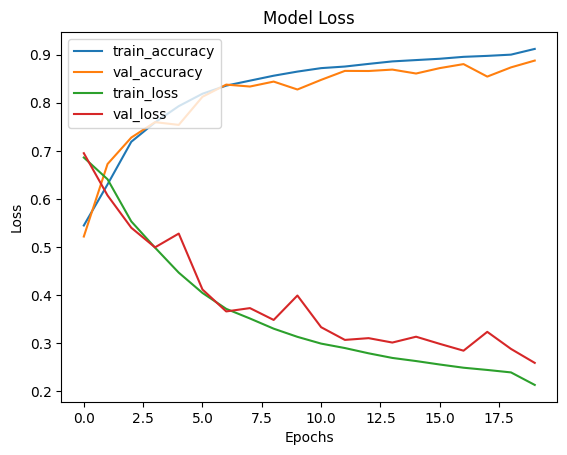

In [3]:
from pathlib import Path
import importlib.util

launcher_path = Path('/kaggle/working/swin-model/ForensiCore-train.py')
if not launcher_path.exists():
    raise FileNotFoundError(f'Missing launcher script: {launcher_path}')

spec = importlib.util.spec_from_file_location('forensicore_launcher', launcher_path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

module.run_video_pipeline()